In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [19]:
# Upload file
with open("Default Dataset.csv", "r") as f:
    lines = f.readlines()

t_data = []
y_data = []

# Clean data
for line in lines:
    # Ignore empty lines
    if line.strip() == "":
        continue

    # Split with ;
    parts = line.strip().split(";")
    
    if len(parts) != 2:
        continue

    x_str, y_str = parts

    # Replace comma with dots 
    x = float(x_str.replace(",", "."))
    y = float(y_str.replace(",", "."))

    t_data.append(x)
    y_data.append(y)

t_data = np.array(t_data)
y_data = np.array(y_data)

print("Loaded points:", len(t_data))

Loaded points: 144


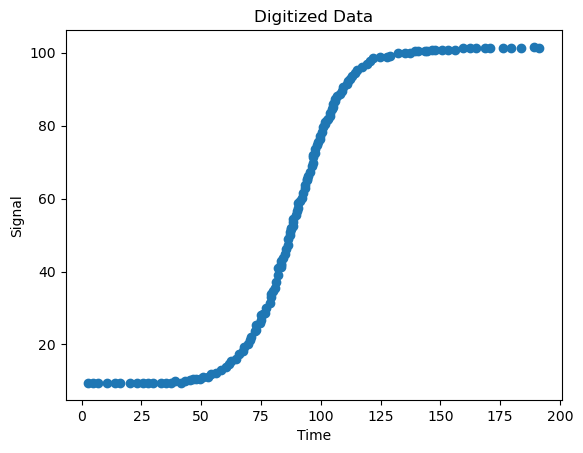

In [21]:
# Check data
plt.scatter(t_data, y_data)
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("Digitized Data")
plt.show()

In [29]:
# Fitting data
def FW_model(t, k1, k2, A0):
    exp_term = np.exp(-(k1 + k2 * A0)* t)
    return (A0 * (1 - exp_term)) / (1 + (k2 * A0 / k1) * exp_term)

p0 = [0.01, 0.1, max(y_data)]

params, _ = curve_fit(FW_model, t_data, y_data, p0=p0, bounds=(0, np.inf), maxfev= 10000)

k1, k2, A0 = params

print("k1 =", k1)
print("k2 =", k2)
print("A0 =", A0)

k1 = 7.106459735011495e-05
k2 = 0.0007845866354288764
A0 = 102.85883352228645


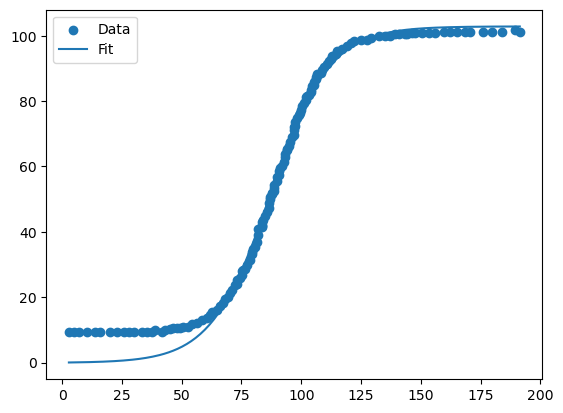

In [31]:
# Plot data
t_fit = np.linspace(min(t_data), max(t_data), 200)
y_fit = FW_model(t_fit, *params)

plt.scatter(t_data, y_data, label="Data")
plt.plot(t_fit, y_fit, label="Fit")
plt.legend()
plt.show()